In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
import scipy.stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cogwheel import gw_prior, gw_plotting, data, waveform, likelihood

In [4]:
prior = gw_prior.IASPrior(
    f_avg=50,
    mchirp_range=(10, 50),
    detector_pair='HL',
    tgps=0,
    ref_det_name='L',
    f_ref=50,
)

In [5]:
def generate_qmc_samples(prior, n_samples, seed=None):
    """
    Sample the parameter space uniformly.
    Note: samples won't correspond to the prior (unless the prior is
    uniform).

    Parameters
    ----------
    n_samples : int
        How many samples to generate.

    seed:
        Passed to ``numpy.default_rng``, for reproducibility.

    Returns
    -------
    pd.DataFrame with columns per
    ``.sampled_params + .standard_params``, with samples distributed
    uniformly.
    """
    samples = pd.DataFrame(
        prior.cubemin + prior.cubesize * scipy.stats.qmc.Halton(
            len(prior.sampled_params), seed=seed).random(n_samples),
        columns=prior.sampled_params)

    prior.transform_samples(samples)
    return samples

In [7]:
samples_aux = generate_qmc_samples(prior, 100)

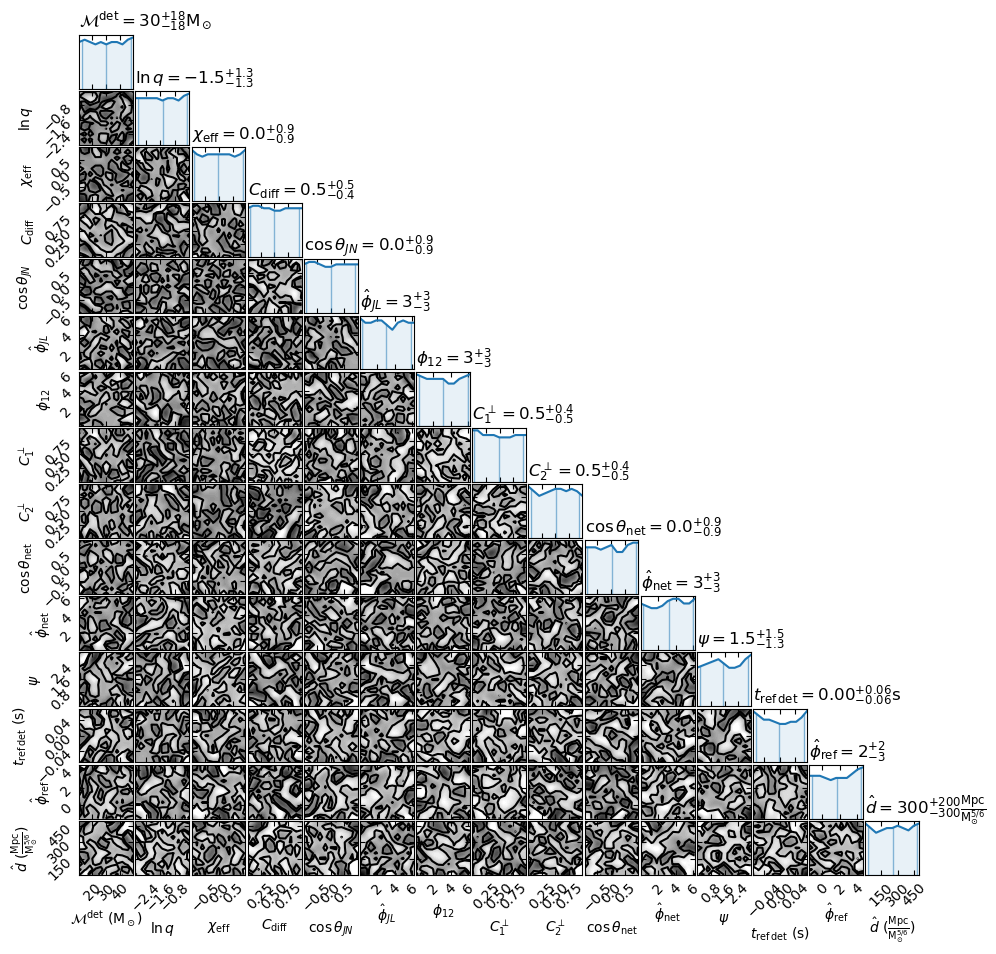

In [25]:
gw_plotting.CornerPlot(samples_aux, prior.sampled_params).plot()

In [ ]:
event_data = data.EventData.gaussian_noise(
    '', 64, 'HLV', ['asd_H_O4', 'asd_L_O4', 'asd_V_O3'], prior.get_init_dict()['tgps'])

wfg = waveform.WaveformGenerator.from_event_data(event_data, 'IMRPhenomXODE')

like = likelihood.CBCLikelihood(event_data, wfg)

In [16]:
samples_aux['h_h'] = [
    like._compute_h_h(like._get_h_f(row)).sum()
    for _, row in samples_aux.iterrows()
]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Modify the distances so the SNR is flat-in-log

In [18]:
samples = samples_aux[prior.standard_params].copy()

In [20]:
# We'll discard the distance column and replace it by a log_snr.
# We implement this as rescaling the distance column so that the snr is
# part of the Halton sequence.
u = scipy.stats.qmc.scale(samples_aux[['d_hat']], *prior.range_dic['d_hat'], reverse=True)[:, 0]
snr_range = 10, 200  # Flat in log
logsnr_min, logsnr_max = np.log(snr_range)
snr = np.exp(logsnr_min + u * (logsnr_max - logsnr_min))
samples['d_luminosity'] = samples_aux['d_luminosity'] * np.sqrt(samples_aux['h_h']) / snr

In [ ]:
# Double check
samples['h_h'] = [
    like._compute_h_h(like._get_h_f(row)).sum()
    for _, row in samples.iterrows()
]

np.allclose(samples['h_h'], snr**2)

/Users/javier/work/GW/cogwheel/cogwheel/plotting.py:523: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.imshow(pdf, origin='lower', aspect='auto', extent=extent,
/Users/javier/work/GW/cogwheel/cogwheel/plotting.py:523: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.imshow(pdf, origin='lower', aspect='auto', extent=extent,


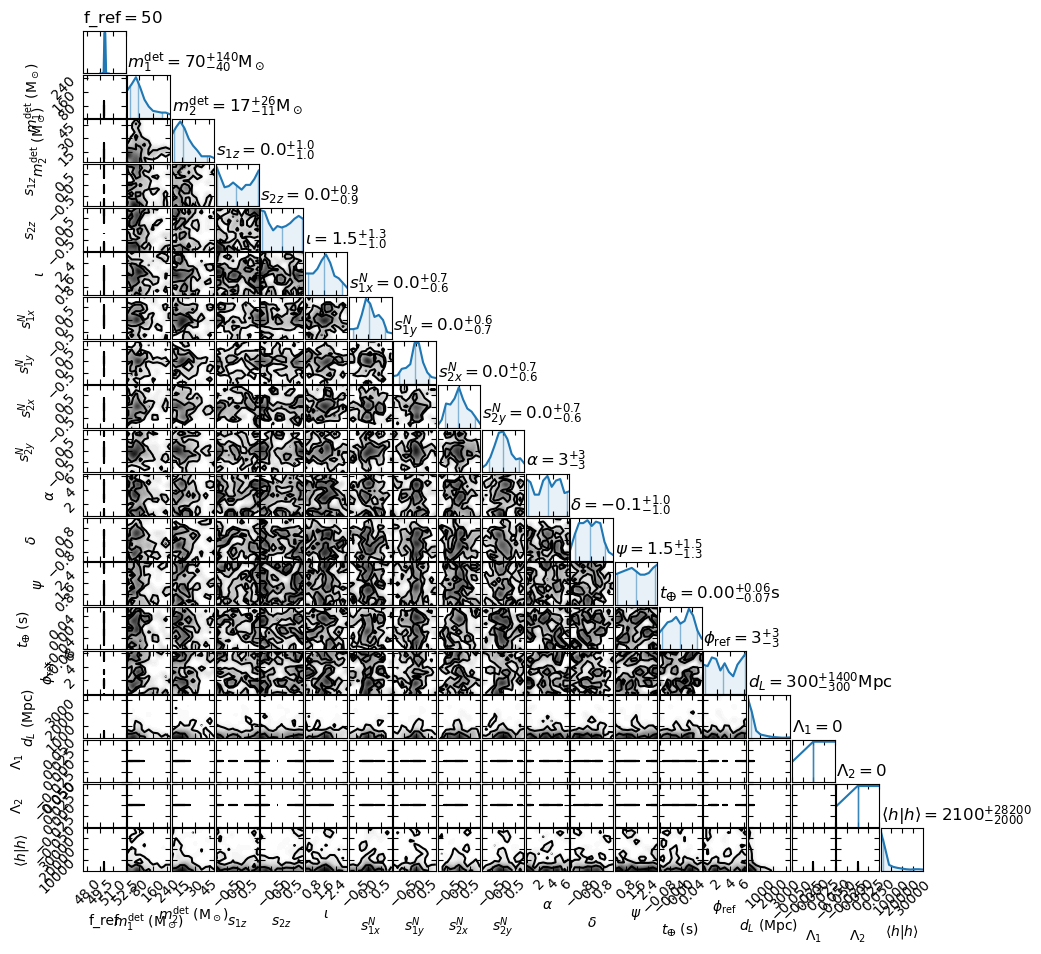

In [24]:
gw_plotting.CornerPlot(samples, prior.standard_params + ['h_h']).plot()

[]

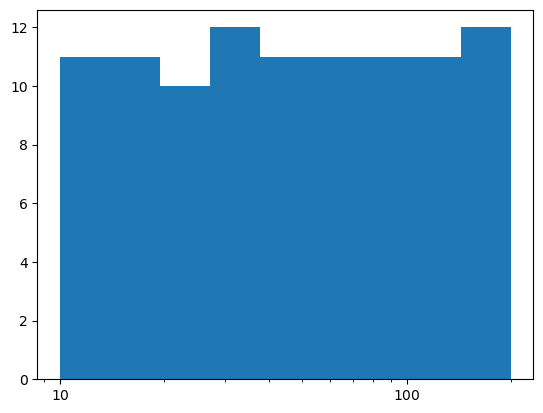

In [29]:
bins = np.geomspace(*snr_range, 10)
plt.hist(snr, bins=bins)
plt.semilogx()

In [ ]:
# Save as:
samples.to_feather(filename)